In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [41]:
url = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

In [42]:
print(f"Total null values : {url.isnull().sum().sum()}")

Total null values : 0


In [43]:
col_containing_null = [col for col in url.columns if url[col].isnull().sum() > 0]
col_containing_null

[]

fig, ax = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2.5, 1]})

missing_data = url[col_containing_null].isnull().sum()
missing_data.plot(kind='bar', ax=ax[0], color='#1f77b4', edgecolor='black')
ax[0].set_title("Missing Data Count per Column", fontsize=14, fontweight='bold')
ax[0].set_ylabel("Count of Missing Values", fontsize=12)
ax[0].set_xticklabels(missing_data.index, rotation=90, ha='right')
ax[0].grid(axis='y')

url['label'].value_counts().plot(kind='bar', ax=ax[1], color=['#2ca02c', '#d62728'])
ax[1].set_title("Legitimate vs Phishing URLs", fontsize=14, fontweight='bold')
ax[1].set_xticklabels(["Legitimate", "Phishing"], rotation=0, fontsize=12)
ax[1].set_ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

url['URLLength'].fillna(url['URL'].apply(len), inplace=True)
url['Domain'].fillna(url['URL'].apply(lambda x: urlparse(x).netloc), inplace=True)
url['DomainLength'].fillna(url['Domain'].apply(len), inplace=True)

def is_ip(domain):
    return bool(re.match(r'^\d{1,3}(\.\d{1,3}){3}$', domain))
url['IsDomainIP'].fillna(url['Domain'].apply(lambda x: 1 if is_ip(x) else 0), inplace=True)
url['TLD'].fillna(url['URL'].apply(lambda x: tldextract.extract(x).suffix), inplace=True)


In [44]:
for col in url.select_dtypes(include=['object']).columns:
    print(f"{col} : {url[col].nunique()}")

FILENAME : 235795
URL : 235370
Domain : 220086
TLD : 695
Title : 197874


In [45]:
title = url[['Title']].copy()
url = url.drop(
    columns = ['FILENAME', 'URL', 'Domain', 'Title']
)
url.shape

(235795, 52)

In [46]:
frequency_dict = url['TLD'].value_counts().to_dict()
url['tld_encoded'] = url['TLD'].map(frequency_dict)

I have used frequency encoding on column TLD (Top-level Domains). The reason for this is because of high number of unique values i.e. 695. Using One-hot encoding would have created additional 695 columns increasing complexity and memory whereas label Encoding assigns arbitrary numbers (0 to 694), which doesn’t provide meaningful information to the model. 

Frequency encoding, on the other hand, captures how common each TLD is in the dataset, which can be useful in identifying phishing trends and also suitable for tree-based models.

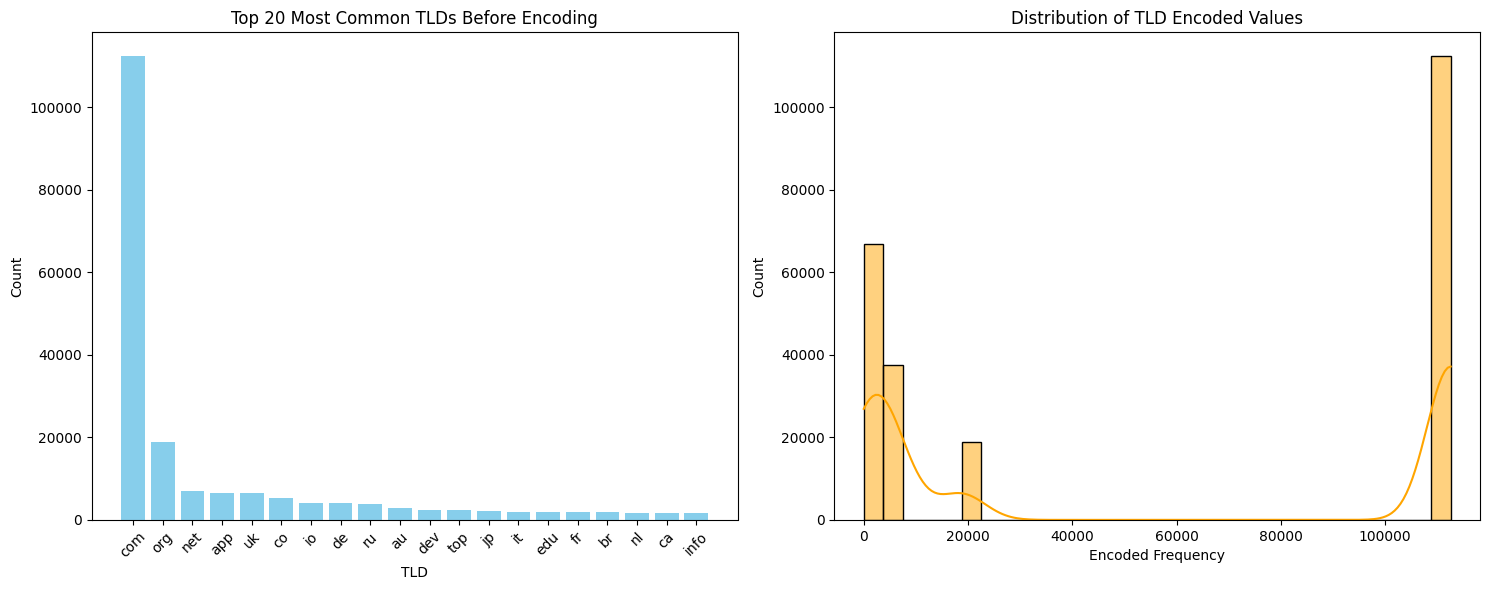

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 6))  
tld_counts = url['TLD'].value_counts().head(20)
ax[0].bar(tld_counts.index, tld_counts.values, color='skyblue')
ax[0].set_title("Top 20 Most Common TLDs Before Encoding")
ax[0].set_xlabel("TLD")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis='x', rotation=45)

sns.histplot(url['tld_encoded'], bins=30, kde=True, color='orange', ax=ax[1])
ax[1].set_title("Distribution of TLD Encoded Values")
ax[1].set_xlabel("Encoded Frequency")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


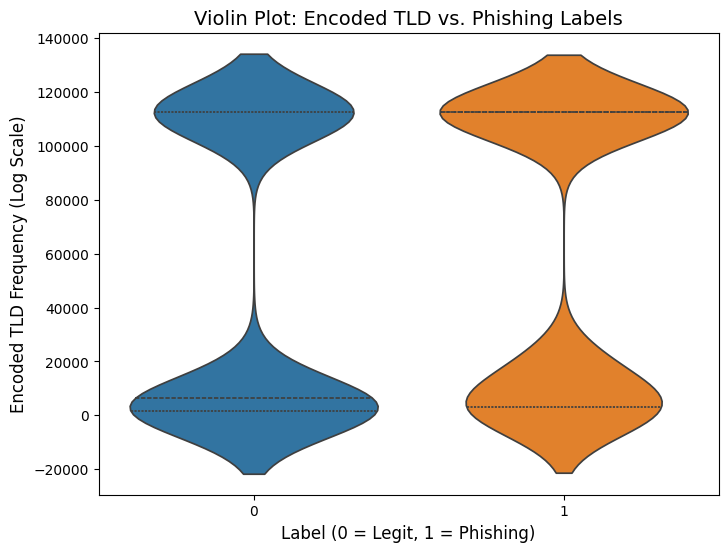

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))

# Improved Violin Plot: Encoded TLD Frequency vs. Phishing Labels
sns.violinplot(x=url["label"],y=url["tld_encoded"], 
    palette=["#1f77b4", "#ff7f0e"],inner="quartile", 
    bw=0.2,ax=ax
)

ax.set_title("Violin Plot: Encoded TLD vs. Phishing Labels", fontsize=14)
ax.set_xlabel("Label (0 = Legit, 1 = Phishing)", fontsize=12)
ax.set_ylabel("Encoded TLD Frequency (Log Scale)", fontsize=12)  
plt.show()